$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 3.4

熵是一种不确定性度量。设有离散集合 $\mathcal{X} = \{\boldsymbol{X}_1, \dots, \boldsymbol{X}_N\}$，以 $\boldsymbol{Y}_\mathcal{X}$ 代表随机向量 $(Y_1, \dots, Y_N)$，其中 $Y_i = h(\boldsymbol{X}_i)$，$h(\cdot)$ 为某随机函数。则 $\boldsymbol{Y}_\mathcal{X}$ 的熵定义为：

$$
Ent(\boldsymbol{Y}_\mathcal{X}) = -\int f(\boldsymbol{y})\log f(\boldsymbol{y})d\boldsymbol{y}
$$

式中 $f(\boldsymbol{y})$ 为 $\boldsymbol{Y}_\mathcal{X}$ 的概率密度函数。优化目标是选取设计 $D$（集合 $\mathcal{X}$ 的子集），由设计 $D$ 可得到观测数据 $\boldsymbol{Y}_D$。我们需要选定设计 $D$，使得在已知观测数据 $\boldsymbol{Y}_D$ 的条件下，未观测数据 $\boldsymbol{Y}_{\mathcal{X}\backslash D}$ 的熵最小。熵存在如下分解形式：

$$
Ent(\boldsymbol{Y}_\mathcal{X}) = Ent(\boldsymbol{Y}_D) + E\{Ent(\boldsymbol{Y}_{\mathcal{X}\backslash D}|\boldsymbol{Y}_D)\}
$$

由于等式左侧与设计 $D$ 无关，因此只需通过最大化 $Ent(\boldsymbol{Y}_D)$ 来最小化等式右侧第二项，由此便得到最大熵设计。

假设输入输出关系由高斯过程实现：$h(\boldsymbol{x})\sim GP(\mu,\tau^2R(\cdot))$，其中 $\mu$、$\tau^2$ 以及相关参数 $\boldsymbol{\theta}$ 均为已知量。设试验设计集合 $D = \{\boldsymbol{x}_i\}_{i=1}^n$，观测数据 $\boldsymbol{y} = (y_1, \dots, y_n)'$，则

$$
\boldsymbol{y} \sim N_n(\mu\boldsymbol{1},\tau^2\boldsymbol{R})
$$

式中 $\boldsymbol{R} = \{R(x_i - x_j)\}_{i,j=1}^n$。我们的目标是选取设计集合 $D$，最大化 $\boldsymbol{y}$ 的熵。$\boldsymbol{y}$ 的熵计算公式如下：

$$
\begin{align*}
Ent(\boldsymbol{y}) &= -\int \left[-\frac{n}{2}\log 2\pi -\frac{n}{2}\log\tau^2 -\frac{1}{2}\log|\boldsymbol{R}| -\frac{1}{2\tau^2}(\boldsymbol{y}-\mu\boldsymbol{1})'\boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1})\right] f(\boldsymbol{y})d\boldsymbol{y}\\
&= \frac{n}{2}\log 2\pi + \frac{n}{2}\log\tau^2 + \frac{1}{2}\log|\boldsymbol{R}| + \frac{1}{2\tau^2}E\left[(\boldsymbol{y}-\mu\boldsymbol{1})'\boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1})\right]\\
&= \frac{n}{2}\log 2\pi + \frac{n}{2}\log\tau^2 + \frac{1}{2}\log|\boldsymbol{R}| + \frac{1}{2\tau^2}tr\left[\boldsymbol{R}^{-1}var(\boldsymbol{y})\right]\\
&= \frac{n}{2}\log 2\pi + \frac{n}{2}\log\tau^2 + \frac{1}{2}\log|\boldsymbol{R}| + \frac{n}{2}
\end{align*}
$$

推导过程用到二次型期望公式：$E(\boldsymbol{y}'\boldsymbol{A}\boldsymbol{y})=E(\boldsymbol{y})'\boldsymbol{A}E(\boldsymbol{y})+tr\{\boldsymbol{A}var(\boldsymbol{y})\}$。剔除不影响优化求解的常数项与对数项，将 $\boldsymbol{y}$ 的熵简化定义为：

$$
Ent(\boldsymbol{y}) := |\boldsymbol{R}|
\tag{3.4}
$$

由此可得最大熵设计满足：

$$
D^*= \argmax_{D} |\boldsymbol{R}|
\tag{3.5}
$$

针对一维问题，在 $R(x)=\exp(−x^2/\theta^2)$、$\theta=0.1$ 的条件下，构造得到一组含 10 个试验点的熵设计，该熵设计与均方根误差变化曲线一同展示于图3.4右侧子图。为便于对比，图 3.2 中的最优积分均方误差设计与最小最大均方误差设计也一并绘于此处。不难发现，相较于积分均方误差最优设计和最小最大均方误差最优设计，熵设计的试验点向区间边界靠拢。最大熵设计与图 3.2 中的等间隔设计形态相近，但其最大均方根误差更小。

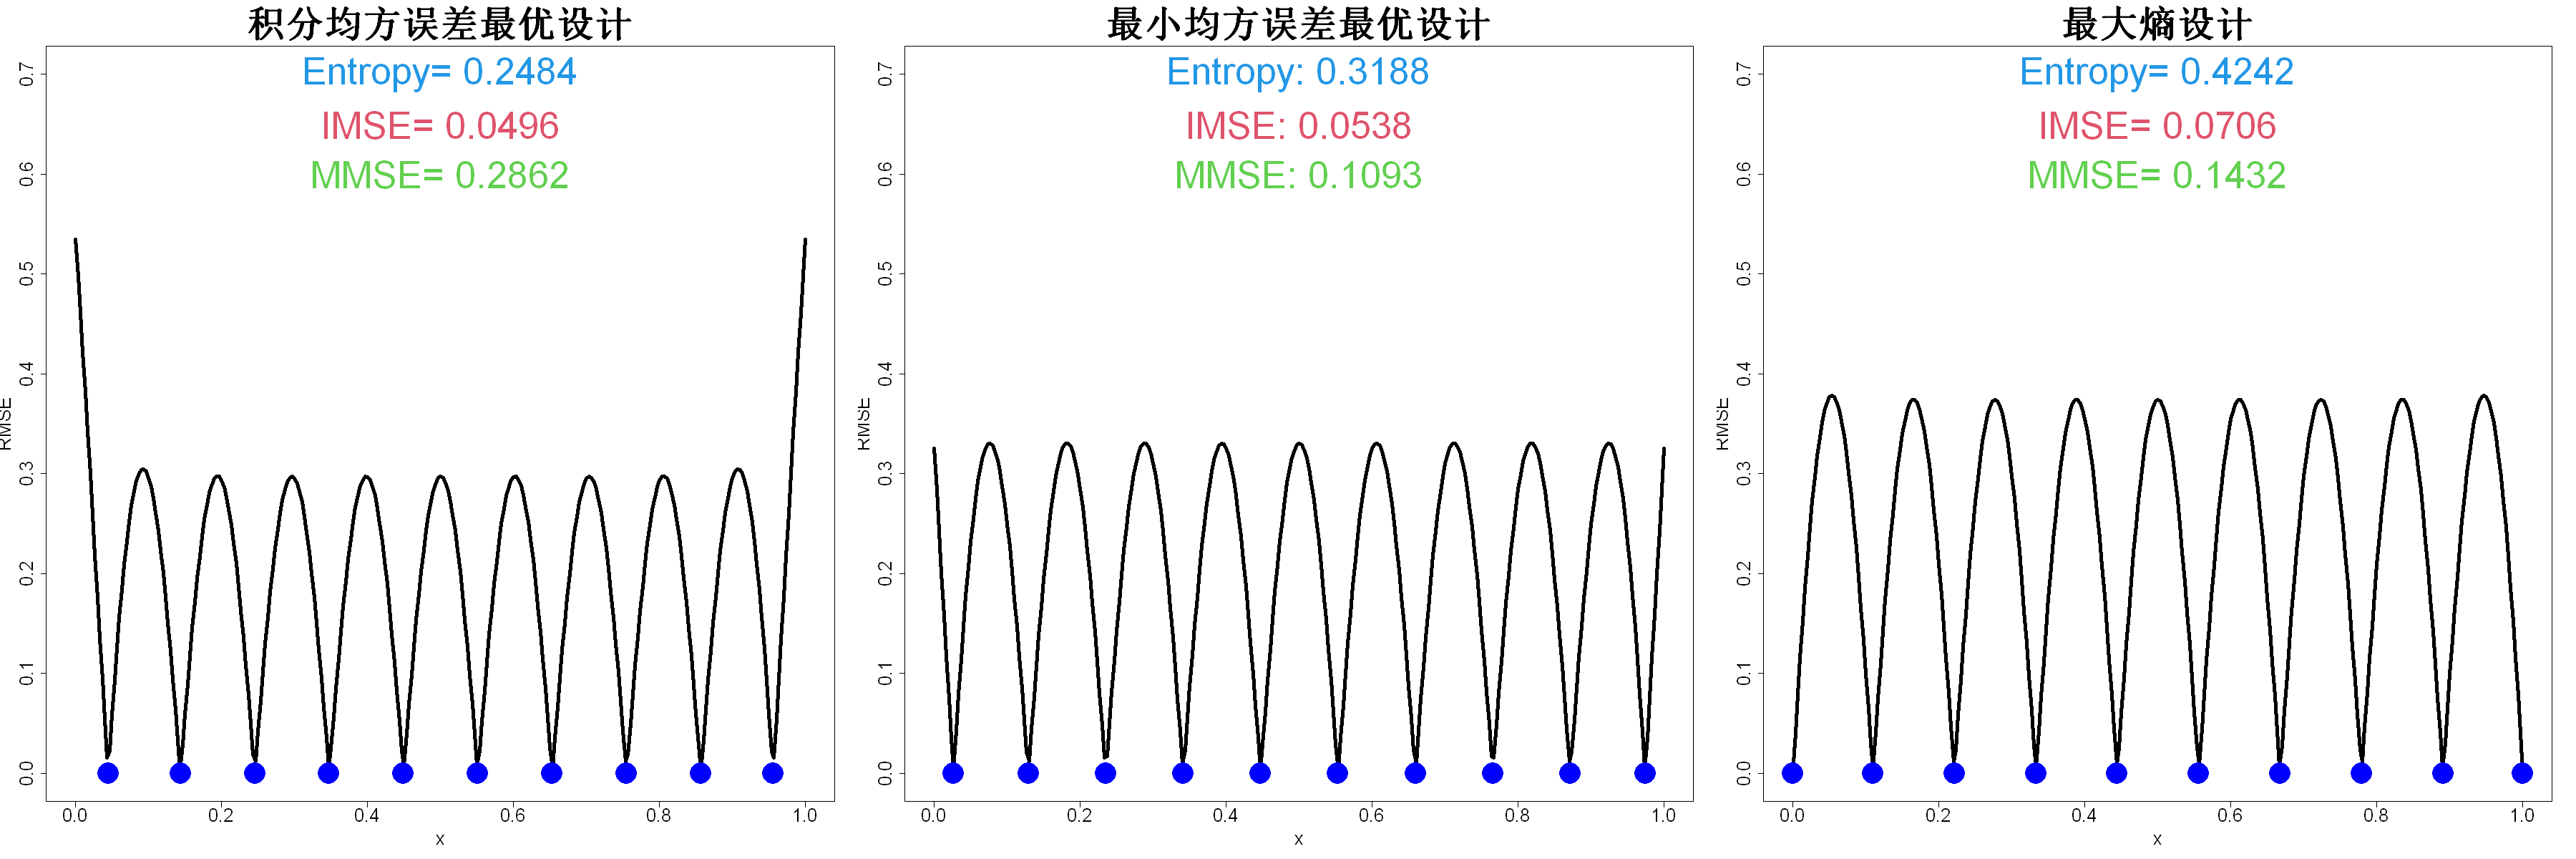

In [2]:
if(!dir.exists("data")){dir.create("data")}
if((!file.exists("data/3.4-D.csv"))||(!file.exists("data/3.4-sa.csv"))||(!file.exists("data/3.4-round.csv"))){
  theta=.1;n=10
  test=seq(0,1,length=301) # 301x1
  D0=((1:n)-.5)/n
  library(gpcrit)
  D1=optim(D0,function(D)imse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par # 10x1
  sa1=gp_rmse(D1,theta,test) # 301x1
  D2=optim(D0,function(D)mmse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par # 10x1
  sa2=gp_rmse(D2,theta,test) # 301x1
  D3=optim(D0,function(D)-entropy(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par # 10x1
  sa3=gp_rmse(D3,theta,test) # 301x1
  ent_D1=entropy(D1,theta);ent_D2=entropy(D2,theta);ent_D3=entropy(D3,theta)
  imse_D1=imse(D1,theta);imse_D2=imse(D2,theta);imse_D3=imse(D3,theta)
  mmse_D1=mmse(D1,theta);mmse_D2=mmse(D2,theta);mmse_D3=mmse(D3,theta)
  write.csv(data.frame(D1=D1,D2=D2,D3=D3),file="data/3.4-D.csv",row.names=FALSE)
  write.csv(data.frame(test=test,sa1=sa1,sa2=sa2,sa3=sa3),file="data/3.4-sa.csv",row.names=FALSE)
  write.csv(data.frame(ent_D1=ent_D1,ent_D2=ent_D2,ent_D3=ent_D3,imse_D1=imse_D1,imse_D2=imse_D2,imse_D3=imse_D3,mmse_D1=mmse_D1,mmse_D2=mmse_D2,mmse_D3=mmse_D3),file="data/3.4-round.csv",row.names=FALSE)
}

df_D=read.csv("data/3.4-D.csv")
D1=df_D$D1;D2=df_D$D2;D3=df_D$D3
criteria=read.csv("data/3.4-round.csv")
ent_D1=criteria$ent_D1;ent_D2=criteria$ent_D2;ent_D3=criteria$ent_D3
imse_D1=criteria$imse_D1;imse_D2=criteria$imse_D2;imse_D3=criteria$imse_D3
mmse_D1=criteria$mmse_D1;mmse_D2=criteria$mmse_D2;mmse_D3=criteria$mmse_D3
sa=read.csv("data/3.4-sa.csv")
test=sa$test;sa1=sa$sa1;sa2=sa$sa2;sa3=sa$sa3

options(repr.plot.width=30,repr.plot.height=10)
par(mfrow=c(1,3))
plot(test,sa1,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="积分均方误差最优设计",cex.main=4,cex.lab=2,cex.axis=2,lwd=4)
points(cbind(D1,0),pch=16,col="blue",cex=5)
text(.5,.7,paste("Entropy=",round(ent_D1,4)),cex=4,col=4)
text(.5,.65,paste("IMSE=",round(imse_D1,4)),cex=4,col=2)
text(.5,.6,paste("MMSE=",round(mmse_D1,4)),cex=4,col=3)
plot(test,sa2,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="最小均方误差最优设计",cex.main=4,cex.lab=2,cex.axis=2,lwd=4)
points(cbind(D2,0),pch=16,col="blue",cex=5)
text(.5,.7,paste("Entropy:",round(ent_D2,4)),cex=4,col=4)
text(.5,.65,paste("IMSE:",round(imse_D2,4)),cex=4,col=2)
text(.5,.6,paste("MMSE:",round(mmse_D2,4)),cex=4,col=3)
plot(test,sa3,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="最大熵设计",cex.main=4,cex.lab=2,cex.axis=2,lwd=4)
points(cbind(D3,0),pch=16,col="blue",cex=5)
text(.5,.7,paste("Entropy=",round(ent_D3,4)),cex=4,col=4)
text(.5,.65,paste("IMSE=",round(imse_D3,4)),cex=4,col=2)
text(.5,.6,paste("MMSE=",round(mmse_D3,4)),cex=4,col=3)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$